In [1]:
import numpy as np

def softmax(values):
    array_values = np.exp(values)
    return array_values / np.sum(array_values)

values = [2, 1, -1, 0.5]

y = softmax(values)
print(y)
y.sum() 

[0.60946004 0.22420782 0.03034323 0.13598892]


1.0

In [2]:
from sklearn import datasets
digit_dataset = datasets.load_digits()
digit_dataset.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [3]:
digit_dataset["images"].shape

(1797, 8, 8)

In [4]:
digit_dataset["target"][0] #정답

0

In [5]:
digit_dataset["images"][0] #데이터

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

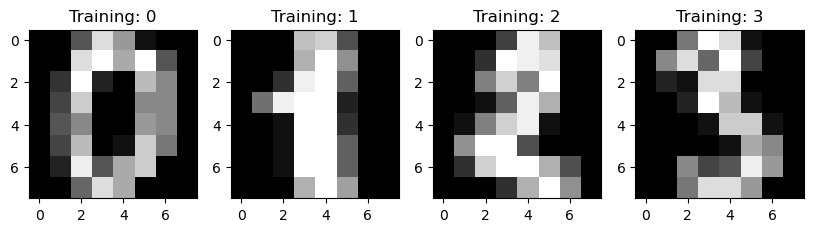

In [6]:
import matplotlib.pyplot as plt

_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3)) 

for i, ax in enumerate(axes):

    image = digit_dataset["images"][i]
    label = digit_dataset["target"][i]

    ax.set_title('Training: %i' % label)
    ax.imshow(image, cmap='gray')

In [7]:
digit_dataset["data"][0].shape

(64,)

In [8]:
from sklearn.model_selection import train_test_split

X = digit_dataset["data"]
y = digit_dataset["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y)#defalut: test_size=0.25
X_train.shape ,  X_test.shape

((1347, 64), (450, 64))

In [9]:
from sklearn.linear_model import LogisticRegression

logreg_ovr = LogisticRegression(multi_class="ovr")
logreg_softmax = LogisticRegression(multi_class="multinomial", solver="sag")

logreg_ovr.fit(X_train, y_train)
logreg_softmax.fit(X_train, y_train)

C:\Users\DANA\.conda\envs\ml\lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\DANA\.conda\envs\ml\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\DANA\.conda\envs\ml\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From th

LogisticRegression(multi_class='multinomial', solver='sag')

In [10]:
from sklearn.metrics import confusion_matrix
y_pred = logreg_ovr.predict(X_test)
y_true = y_test.copy()
cm = confusion_matrix(y_true, y_pred)
cm

array([[48,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 35,  0,  0,  0,  0,  0,  0,  2,  0],
       [ 0,  0, 46,  1,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 34,  0,  0,  0,  1,  0,  1],
       [ 0,  0,  0,  0, 41,  0,  0,  0,  0,  0],
       [ 0,  1,  0,  0,  0, 52,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0, 43,  0,  1,  0],
       [ 0,  0,  0,  0,  0,  0,  0, 51,  0,  1],
       [ 0,  2,  1,  2,  0,  0,  0,  0, 47,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0, 40]], dtype=int64)

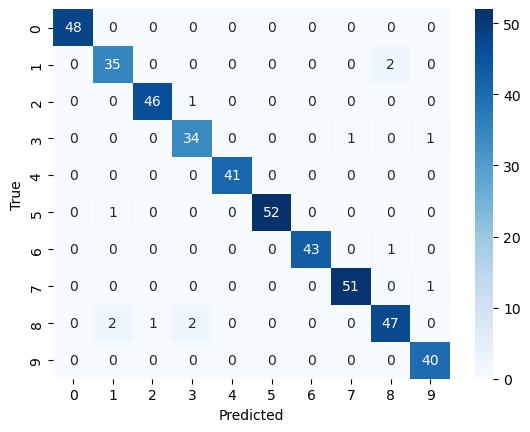

In [11]:
import seaborn as sns

sns.heatmap(cm, annot=True, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [12]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        48
           1       0.92      0.95      0.93        37
           2       0.98      0.98      0.98        47
           3       0.92      0.94      0.93        36
           4       1.00      1.00      1.00        41
           5       1.00      0.98      0.99        53
           6       1.00      0.98      0.99        44
           7       0.98      0.98      0.98        52
           8       0.94      0.90      0.92        52
           9       0.95      1.00      0.98        40

    accuracy                           0.97       450
   macro avg       0.97      0.97      0.97       450
weighted avg       0.97      0.97      0.97       450



In [13]:
import numpy as np
from sklearn.metrics import roc_curve, auc

y_true = np.array([0, 0, 1, 1])# 실제 클래스 (0 = negative, 1 = positive)
pred = np.array([0.1, 0.4, 0.35, 0.8])# positive 클래스(양성 클래스)의 예측 확률

fpr, tpr, thresholds = roc_curve(y_true, pred, pos_label=1)
roc_auc = auc(fpr, tpr)

# 결과 출력
print("FPR:", fpr)
print("TPR:", tpr)
print("Thresholds:", thresholds)
print("AUC:", roc_auc)

FPR: [0.  0.  0.5 0.5 1. ]
TPR: [0.  0.5 0.5 1.  1. ]
Thresholds: [ inf 0.8  0.4  0.35 0.1 ]
AUC: 0.75


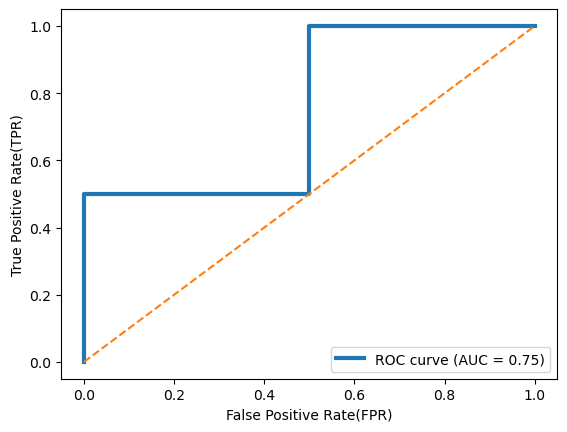

In [14]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr, lw=3, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate(FPR)')
plt.ylabel('True Positive Rate(TPR)')
plt.legend(loc="lower right")
plt.show()

In [15]:
import pandas as pd

y_bin = pd.get_dummies(y_test).values#실제값을 one-hot 형태로 변환
pred = logreg_ovr.predict_proba(X_test)

#클래스 수
n_classes = pred.shape[1]

#클래스별 ROC 계산
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

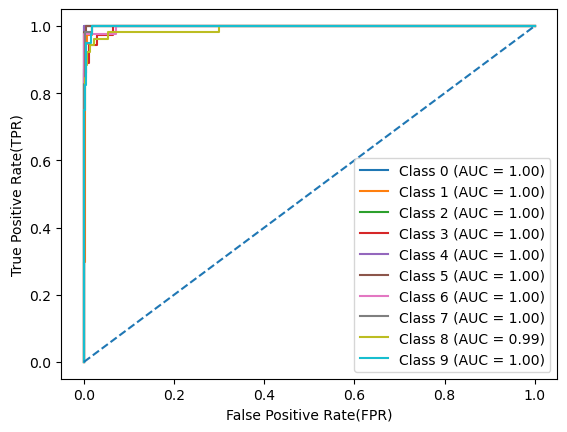

In [16]:
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate(FPR)')
plt.ylabel('True Positive Rate(TPR)')
plt.legend(loc="lower right")
plt.show()